<h1> Portuguese bank project</h1>

<h4> Team ID:  PTID-CDS-MAR-26-4098 <br><br>
Project ID: PRCP-1000-ProtugeseBank </h4>

<ul type='circle'>
    <li><h4>Team Members: Om Jadhav,Sakshi Khakare</h4></li>
    <li><h4>Domain: Finance & Banking</h4></li>
</ul>
<hr>

<h2>About Dataset</h2>
<ul type='circle'>
    <li><h4>Name: bank-additional-full.csv</h4></li>
    <li><h4>Rows: 41188</h4></li>
    <li><h4>Columns: 21</h4></li>
    <li><h4>Target variable: y</h4></li>
</ul>
<hr>

<h3>Methodology</h3>
<ol type='1'>
    <li><h4>Data loading</h4></li>
    <ul type='circle'>
        <li><h4>Importing data</h4></li>
        <li><h4>Understanding its nature and features</h4></li>
    </ul>
    <li><h4>EDA</h4></li>
    <ul type='circle'>
        <li><h4>Targetwise feature comparision</h4></li>
        <li><h4>Understanding correlations between variables using heatmaps</h4></li>
    </ul>
    <li><h4>Data preprocessing</h4></li>
    <ul type='circle'>
        <li><h4>Outlier handling</h4></li>
        <li><h4>Converting categorical values into numerical values using One hot encoding</h4></li>
    </ul>
    <li><h4>Model training</h4></li>
    <ul type='circle'>
        <li><h4>Trained various supervised learining classification models</h4></li>
        <li><h4>Following models were implemented:</h4></li>
        <ul type='square'>
            <li><h4>Logistic Regression</h4></li>
            <li><h4>Support Vector Classifier</h4></li>
            <li><h4>Decsion Tree Classifier</h4></li>
            <li><h4>Random Forest Classifier</h4></li>
            <li><h4>K-Nearest Classifier</h4></li>
        </ul>
    </ul>
</ol>
<hr>

<h3>Importing all necessary modules </h3>

In [9]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay,precision_recall_curve
from sklearn.metrics import roc_auc_score,roc_curve
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.neighbors import KNeighborsClassifier

<hr>

<h3>Importing dataset and finding its insights</h3>

In [11]:
df=pd.read_csv(r"bank-additional-full.csv",sep=';')
#challenge faced: this file is actually colon separated instead of comma separated , to solve this used sep=';' in read_csv() to separate data

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.shape

(41188, 21)

Categorical variables

In [6]:
df.select_dtypes(include='object').columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

Numerical variables

In [7]:
df.select_dtypes(exclude='object').columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [8]:
df.isnull().sum()[df.isnull().sum()>0]

Series([], dtype: int64)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [10]:
df.select_dtypes(exclude='object').describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


<hr>

<h3>Exploratory data analysis</h3>

Correlation matrix

In [13]:
correlation_matrix=df.select_dtypes(exclude='object').corr().abs()
correlation_matrix

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,0.004594,0.034369,0.024365,0.000371,0.000857,0.129372,0.010767,0.017725
campaign,0.004594,1.000000,0.052584,0.079141,0.150754,0.127836,0.013733,0.135133,0.144095
pdays,0.034369,0.052584,1.000000,0.587514,0.271004,0.078889,0.091342,0.296899,0.372605
previous,0.024365,0.079141,0.587514,1.000000,0.420489,0.203130,0.050936,0.454494,0.501333
emp.var.rate,0.000371,0.150754,0.271004,0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.127836,0.078889,0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,0.013733,0.091342,0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,0.135133,0.296899,0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,0.017725,0.144095,0.372605,0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


Correlation heaptmap

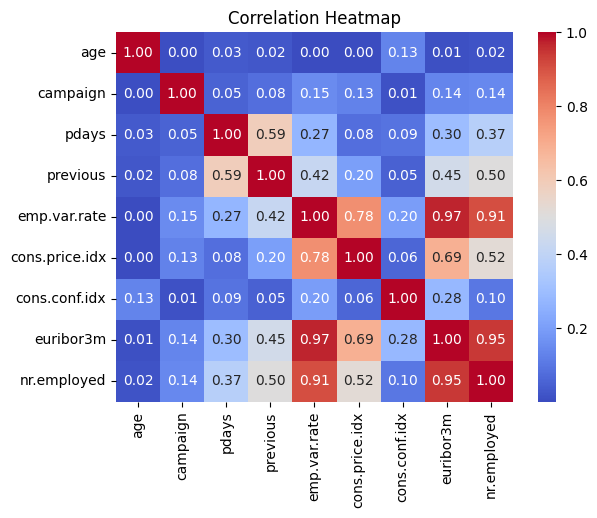

In [14]:
sns.heatmap(correlation_matrix,cmap='coolwarm',annot=True,fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

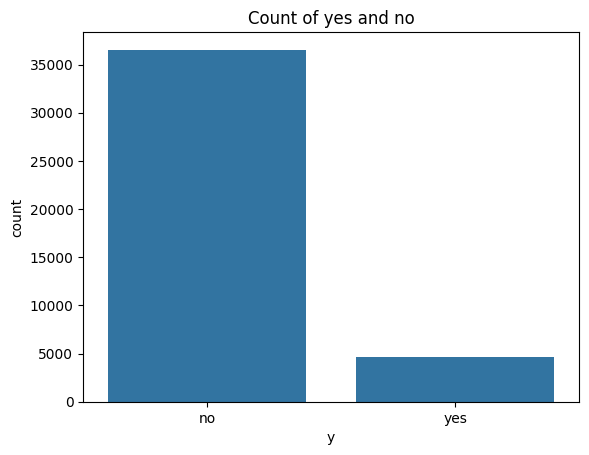

In [18]:
sns.countplot(x=df['y'],data=df)
plt.title("Count of yes and no")
plt.show()

Age distribution

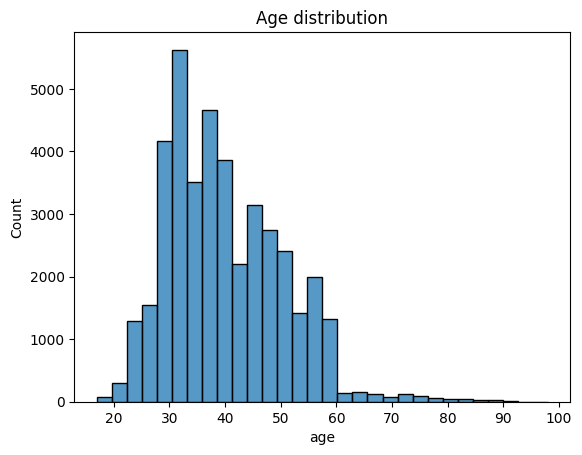

In [25]:
sns.histplot(x=df['age'],bins=30)
plt.title('Age distribution')
plt.show()

Job type count

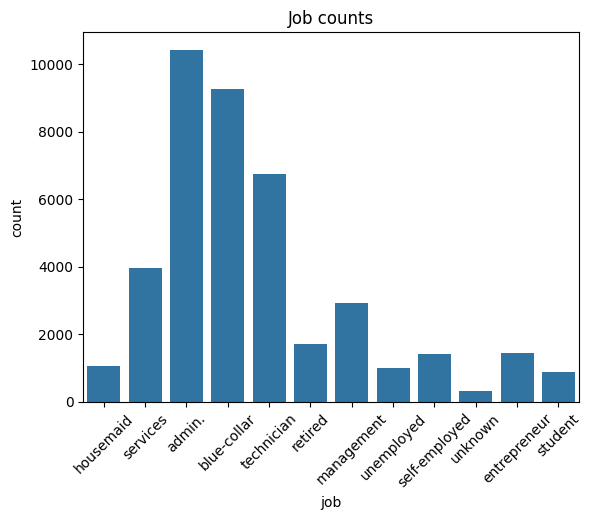

In [29]:
sns.countplot(x=df['job'],data=df)
plt.xticks(rotation=45)
plt.title("Job counts")
plt.show()

[]

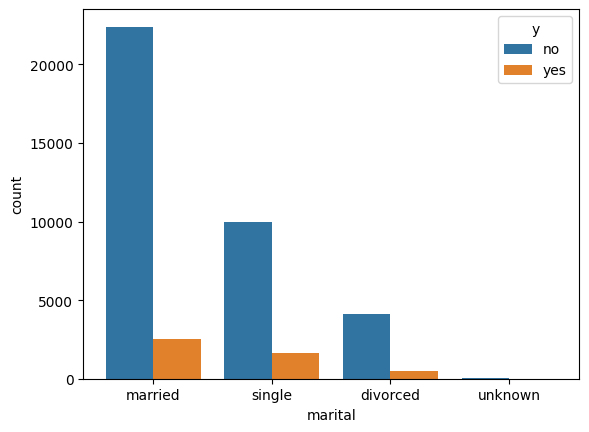

In [13]:
sns.countplot(x=df['marital'],hue=df['y'],data=df)
plt.plot()

In [5]:
df.month.value_counts()

month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64

<hr>

<h3>Data Cleaning</h3>

Replacing outliers with mode

In [5]:
df.default.replace("unknown", df['default'].mode()[0], inplace=True)
df.education.replace("unknown", df['education'].mode()[0], inplace=True)
df.housing.replace("unknown", df['housing'].mode()[0], inplace=True)
df.loan.replace("unknown", df['loan'].mode()[0], inplace=True)
df.job.replace("unknown", df['job'].mode()[0], inplace=True)
df.marital.replace("unknown", df['marital'].mode()[0], inplace=True)

In [6]:
#mapping binary columns
binary_cols=['default','housing','loan']
for col in binary_cols:
    df[col]=df[col].map({'no':0,'yes':1,'unknown':-1})


In [7]:
df.y.replace({'no':0,'yes':1},inplace=True)


In [8]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,0,0,0,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,0,0,0,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,0,1,0,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,0,0,0,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,0,0,1,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


Performing one hot encoding

In [9]:
df=pd.get_dummies(df,columns=['job','marital','education','contact','month','day_of_week','poutcome'],drop_first=True)

In [10]:
df.head()

,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,0,0,0,261,1,999,0,1.1,93.994,...,True,False,False,False,True,False,False,False,True,False
1,57,0,0,0,149,1,999,0,1.1,93.994,...,True,False,False,False,True,False,False,False,True,False
2,37,0,1,0,226,1,999,0,1.1,93.994,...,True,False,False,False,True,False,False,False,True,False
3,40,0,0,0,151,1,999,0,1.1,93.994,...,True,False,False,False,True,False,False,False,True,False
4,56,0,0,1,307,1,999,0,1.1,93.994,...,True,False,False,False,True,False,False,False,True,False


In [11]:
df.replace({True:1,False:0},inplace=True)

In [12]:
df.head()

,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,0,0,0,261,1,999,0,1.1,93.994,...,1,0,0,0,1,0,0,0,1,0
1,57,0,0,0,149,1,999,0,1.1,93.994,...,1,0,0,0,1,0,0,0,1,0
2,37,0,1,0,226,1,999,0,1.1,93.994,...,1,0,0,0,1,0,0,0,1,0
3,40,0,0,0,151,1,999,0,1.1,93.994,...,1,0,0,0,1,0,0,0,1,0
4,56,0,0,1,307,1,999,0,1.1,93.994,...,1,0,0,0,1,0,0,0,1,0


Splitting dependent and independent variables

In [13]:
X=df.drop('y',axis=1)
y=df['y']

Splitting data into training and testing

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

Scaling data

In [15]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

<hr>

<h3>Logistic Regression</h3>

In [16]:
logreg=LogisticRegression(class_weight='balanced')
logreg.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [17]:
predicted_values=logreg.predict(X_test)

In [18]:
matrix=confusion_matrix(y_test,predicted_values)
matrix

array([[6280, 1030],
       [  83,  845]])

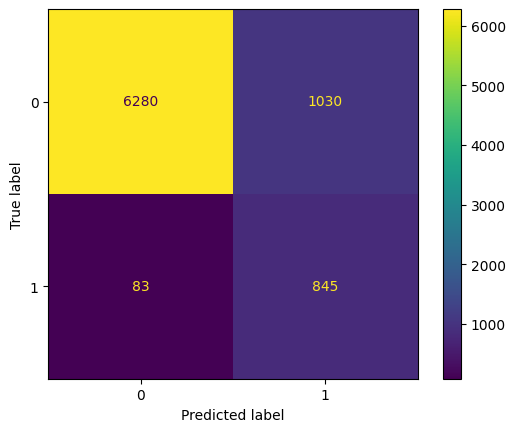

In [19]:
matrix_display=ConfusionMatrixDisplay(confusion_matrix=matrix)
matrix_display.plot()

In [20]:
accuracy_score(y_test,predicted_values)

0.8648943918426802

In [21]:
precision_score(y_test,predicted_values)

0.45066666666666666

In [22]:
recall_score(y_test,predicted_values)

0.9105603448275862

In [23]:
f1_score(y_test,predicted_values)

0.6029254370317517

In [34]:
y_probs=logreg.predict_proba(X_test)[:,1]
y_probs

array([0.40178519, 0.69797044, 0.61403921, ..., 0.60206819, 0.16986413,
       0.28992883], shape=(8238,))

In [31]:
for t in [0.3,0.5,0.6,0.7,0.8]:
    y_pred = (y_probs >= t).astype(int)
    print(t, precision_score(y_test, y_pred))

0.3 0.13925311203319501
0.5 0.3254060324825986
0.6 0.4226086956521739
0.7 0.5167394468704513
0.8 0.5533596837944664


<hr>

<h3>Support Vector Classification</h3>

In [33]:
svc=SVC(kernel='poly',class_weight='balanced')

In [34]:
svc.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [35]:
pred=svc.predict(X_test)

In [36]:
confusion_matrix(y_test,pred)

array([[6412,  898],
       [ 155,  773]])

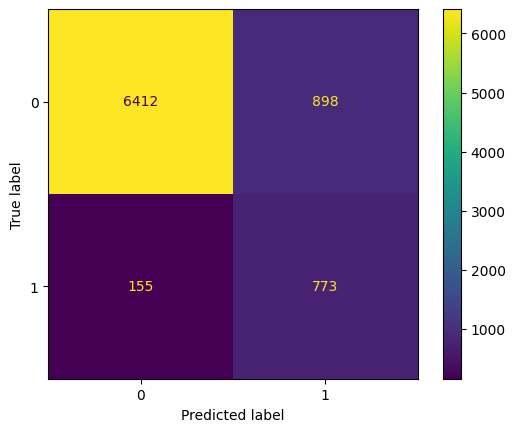

In [37]:
matrix=confusion_matrix(y_test,pred)
matrix_display=ConfusionMatrixDisplay(confusion_matrix=matrix)
matrix_display.plot()

In [38]:
accuracy_score(y_test,pred)

0.872177713037145

In [39]:
precision_score(y_test,pred)

0.46259724715739076

In [40]:
recall_score(y_test,pred)

0.8329741379310345

In [41]:
f1_score(y_test,pred)

0.5948441708349365

<hr>

<h3>Decision Tree Regression</h3>

In [44]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [64]:
#using above hyperparameters
dtc=DecisionTreeClassifier(random_state=42,class_weight='balanced',max_depth=5,min_samples_leaf=5,min_samples_split=2)

In [65]:
dtc.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [66]:
pred=dtc.predict(X_test)

In [67]:
confusion_matrix(y_test,pred)

array([[6125, 1185],
       [  84,  844]])

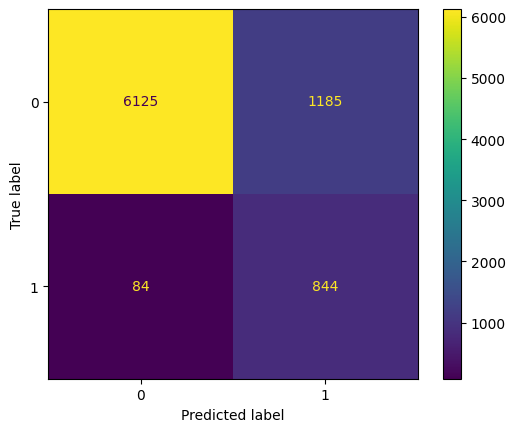

In [68]:
matrix=confusion_matrix(y_test,pred)
matrix_display=ConfusionMatrixDisplay(confusion_matrix=matrix)
matrix_display.plot()

In [69]:
accuracy_score(y_test,pred)

0.8459577567370721

In [70]:
recall_score(y_test,pred)

0.9094827586206896

In [71]:
precision_score(y_test,pred)

0.4159684573681617

In [72]:
f1_score(y_test,pred)

0.5708488332769699

<hr>

<h3>Random Forest Classifier</h3>

In [75]:


param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [76]:
rfc=RandomForestClassifier(random_state=42,class_weight='balanced',max_depth=10,min_samples_leaf=2,min_samples_split=5)

In [77]:
rfc.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [78]:
pred=rfc.predict(X_test)

In [79]:
confusion_matrix(y_test,pred)

array([[6262, 1048],
       [  60,  868]])

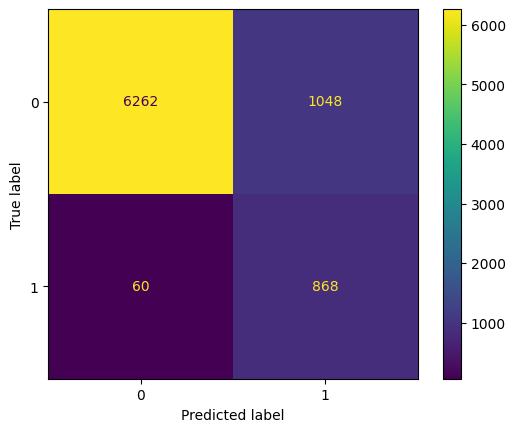

In [80]:
matrix=confusion_matrix(y_test,pred)
matrix_display=ConfusionMatrixDisplay(confusion_matrix=matrix)
matrix_display.plot()

In [81]:
accuracy_score(y_test,pred)

0.8655013352755523

In [82]:
precision_score(y_test,pred)

0.453027139874739

In [83]:
recall_score(y_test,pred)

0.9353448275862069

In [84]:
f1_score(y_test,pred)

0.6104078762306611

<hr>

<h3>K-Nearest Neighbours</h3>

In [87]:
#choosing best value for K
param_grid = {'n_neighbors': list(range(1, 31, 2))}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best K
print("Best K:", grid_search.best_params_['n_neighbors'])

Best K: 29


In [88]:
knc=KNeighborsClassifier(n_neighbors=29,weights='distance')

In [89]:
knc.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",29
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [93]:
pred=knc.predict(X_test)

In [94]:
confusion_matrix(y_test,pred)

array([[7188,  122],
       [ 676,  252]])

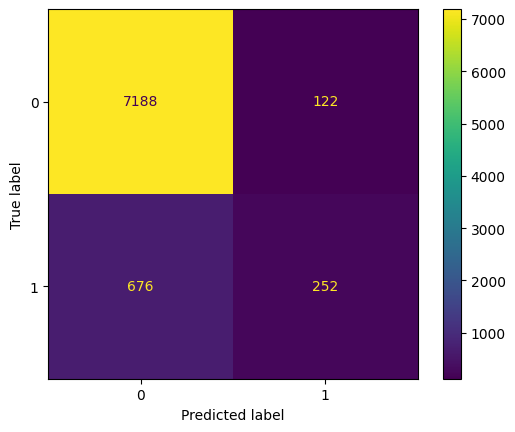

In [95]:
matrix=confusion_matrix(y_test,pred)
matrix_display=ConfusionMatrixDisplay(confusion_matrix=matrix)
matrix_display.plot()

In [96]:
accuracy_score(y_test,pred)

0.9031318281136198

In [97]:
recall_score(y_test,pred)

0.27155172413793105

In [98]:
precision_score(y_test,pred)

0.6737967914438503

In [99]:
f1_score(y_test,pred)

0.3870967741935484

<hr>

<h3>Comparing performance of each model</h3>

[]

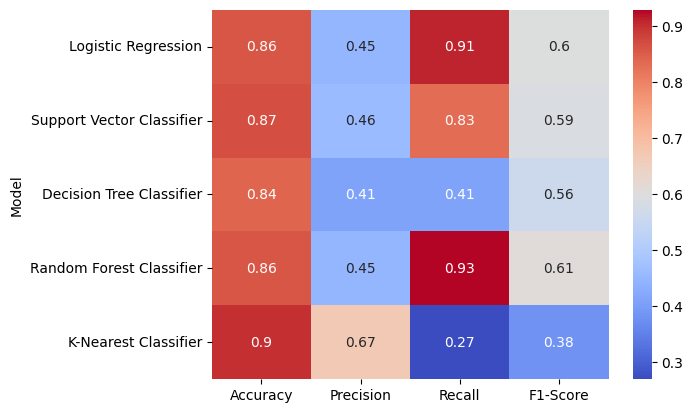

In [114]:
performance_metrics=pd.DataFrame({
    "Model":["Logistic Regression","Support Vector Classifier","Decision Tree Classifier","Random Forest Classifier","K-Nearest Classifier"],
    "Accuracy":[0.86,0.87,0.84,0.86,0.9],
    "Precision":[0.45,0.46,0.41,0.45,0.67],
    "Recall":[0.91,0.83,0.41,0.93,0.27],
    "F1-Score":[0.6,0.59,0.56,0.61,0.38]
})
performance_metrics.set_index("Model",inplace=True)
#plotting heatmap
sns.heatmap(performance_metrics,annot=True,cmap='coolwarm')
plt.plot()

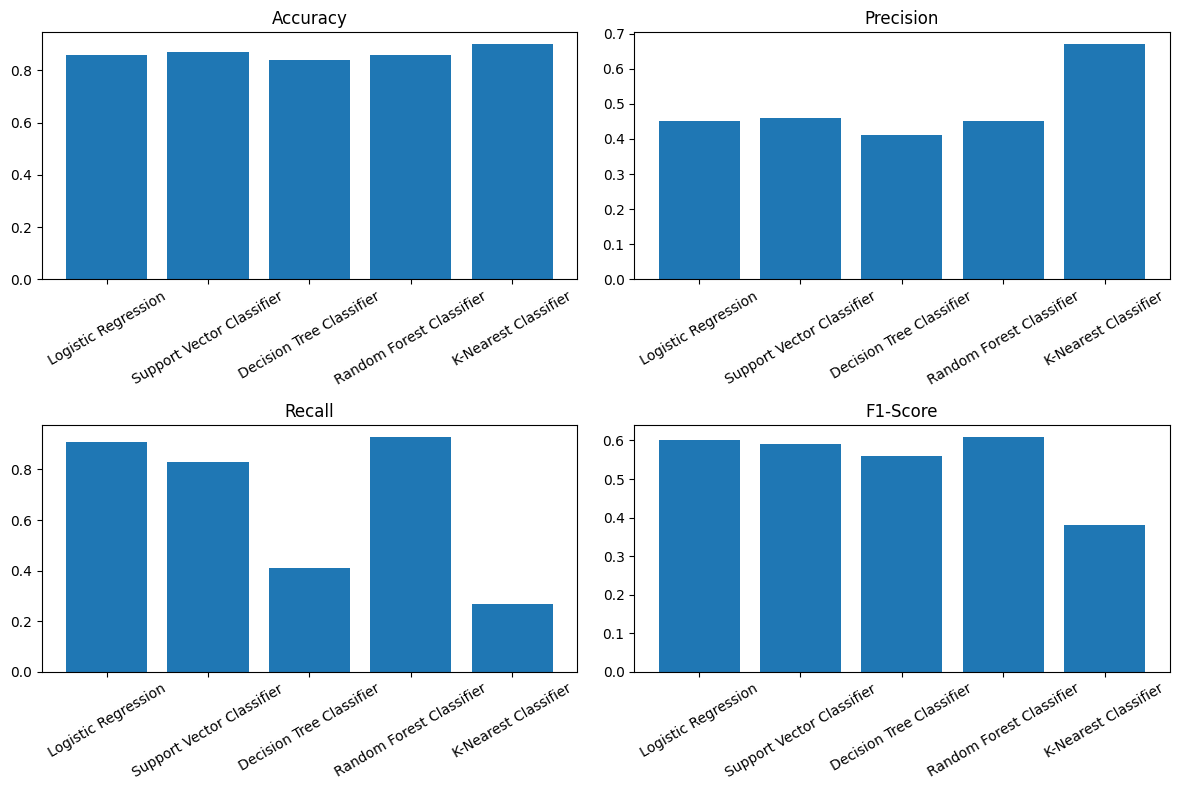

In [128]:
fig,axes=plt.subplots(2,2,figsize=(12,8))
axes=axes.flatten()
for i,col in enumerate(performance_metrics.columns):
    axes[i].bar(performance_metrics.index,performance_metrics[col])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x',rotation=30)
plt.tight_layout()
plt.show()

<hr>

<h3>Final Conclusion</h3>

<h4>All the models that were trained and evaluated to predict customer subscription to term deposits using portuguese bank dataset.The models are 
compared based on their precision and recall, not just accuracy.</h4> <br>

<ol type='1'>
    <li><h4>Logistic regression has performed well on all parameters.<h4></li>
    <li><h4>Support Vector Classifier is slightly behind logistic regression.</h4></li>
    <li><h4>Decision Tree Classifier lacks in recall and hence is not a viable option.</h4></li>
    <li><h4>Random Forest Classifier has better precision and recall than Logistic regression and Support Vector Classifier due to its ability 
    to handle non linear data.</h4></li>
    <li><h4>K-Nearest Classifier has poor recall making it infeasible option.</h4></li>
</ol>
<h4>Hence Random Forest Classifier is the best option for this data set due to its non-linear nature.</h4>